In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import gzip
import shutil
import numpy as np
with gzip.open('data_3.4/RT.fits.gz', 'rb') as f_in:
    with open('data_3.4/RT.fits', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
with gzip.open('data_th/Temperature.fits.gz', 'rb') as f_in:
    with open('data_th/Temperature.fits', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

Filename: data_3.4/RT.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      24   (30, 30, 1, 1, 1)   float32   
  1                1 ImageHDU        10   (1, 1, 1, 2)   float32   
  2                1 ImageHDU         9   (1, 1, 1)   float32   
  3                1 ImageHDU         8   (3, 1)   float32   
1.4789784e-12


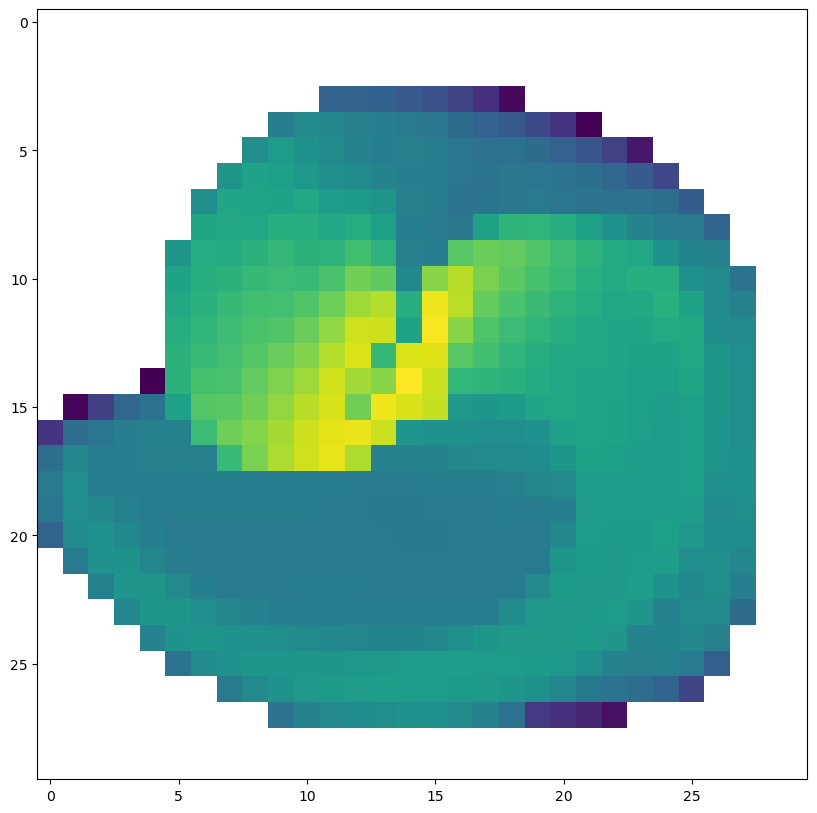

In [2]:
hdul = fits.open("data_3.4/RT.fits")
hdul.info()

data = hdul[0].data[0][0][0]

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(data[::-1, :], cmap='viridis', norm='log')

fig.savefig('image.png', dpi=400)

print(np.sum(data))

Filename: data_th/Temperature.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (102396,)   float32   


(array([8.000e+00, 2.100e+01, 5.400e+01, 1.660e+02, 4.310e+02, 1.004e+03,
        2.032e+03, 3.054e+03, 3.985e+03, 4.385e+03, 4.034e+03, 3.685e+03,
        3.333e+03, 3.094e+03, 2.862e+03, 3.050e+03, 2.874e+03, 2.525e+03,
        2.533e+03, 2.717e+03, 2.631e+03, 2.313e+03, 1.761e+03, 1.620e+03,
        1.673e+03, 1.900e+03, 2.041e+03, 1.942e+03, 2.005e+03, 2.085e+03,
        2.021e+03, 1.867e+03, 1.677e+03, 1.506e+03, 1.338e+03, 1.310e+03,
        1.177e+03, 1.229e+03, 1.169e+03, 1.146e+03, 1.131e+03, 1.133e+03,
        1.094e+03, 1.038e+03, 1.011e+03, 1.002e+03, 9.820e+02, 9.560e+02,
        9.010e+02, 8.960e+02, 8.630e+02, 8.150e+02, 7.770e+02, 7.740e+02,
        7.400e+02, 7.270e+02, 7.080e+02, 6.490e+02, 6.490e+02, 6.570e+02,
        6.300e+02, 6.080e+02, 6.350e+02, 5.910e+02, 6.010e+02, 5.580e+02,
        4.900e+02, 3.000e+02, 1.550e+02, 5.400e+01, 1.000e+01, 2.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

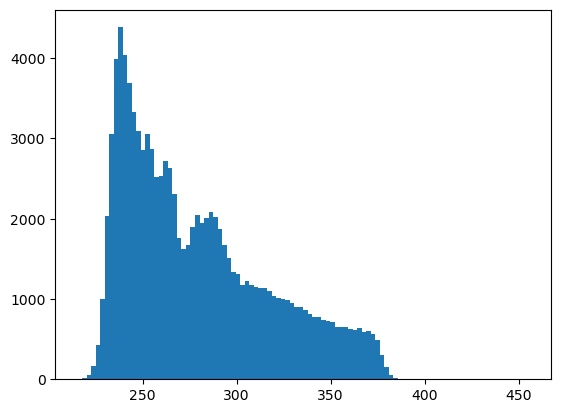

In [3]:

temps = fits.open("data_th/Temperature.fits")
temps.info()

temp_data = temps[0].data

fig, ax = plt.subplots()
ax.hist(temp_data, bins=100)

In [4]:
raw_densities = fits.open("apep1shell.fits")
raw_densities.info()

masses = raw_densities[0].data
weights = masses / max(masses)

particles = raw_densities[1].data
print(particles.shape)

Filename: apep1shell.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   (102398,)   float64   
  1                1 ImageHDU         7   (3, 102398)   float64   
(102398, 3)


/tmp/ipykernel_126700/798996632.py:11: RuntimeWarning: invalid value encountered in divide
  H /= H_norm


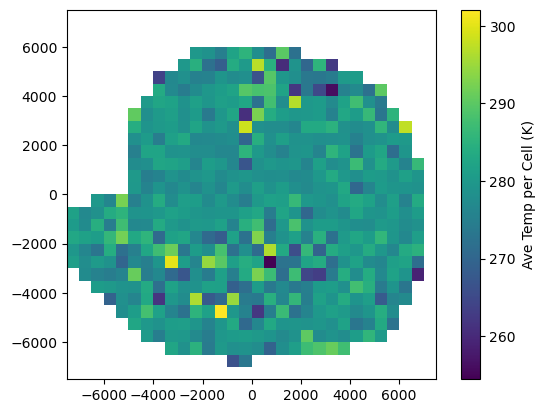

In [5]:
import numpy as np

resolution = hdul[0].data[0][0][0].shape[0]
indices = range(len(temp_data))
bound = np.max(np.abs(particles[indices, :2]))
pixels = np.linspace(-bound, bound, resolution + 1)

H, x, y = np.histogram2d(particles[indices, 0], particles[indices, 1], bins=pixels, weights=temp_data)
H_norm, x, y = np.histogram2d(particles[indices, 0], particles[indices, 1], bins=pixels)

H /= H_norm

fig, ax = plt.subplots()

# ax.scatter(particles[indices, 0], particles[indices, 1], c=temp_data, s=0.1)
# ax.set(aspect='equal')
p = ax.pcolormesh(x, y, H.T)
ax.set(aspect='equal')
fig.colorbar(p, label='Ave Temp per Cell (K)')

In [6]:
wcs

NameError: name 'wcs' is not defined